In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
nav_history = pd.read_csv(r"C:\Users\puvvu\OneDrive\ドキュメント\MutualFundProject\data\processed\02_nav_history_cleaned.csv")

performance = pd.read_csv(r"C:\Users\puvvu\OneDrive\ドキュメント\MutualFundProject\data\processed\07_scheme_performance_cleaned.csv")

benchmark = pd.read_csv(r"C:\Users\puvvu\OneDrive\ドキュメント\MutualFundProject\data\processed\10_benchmark_indices_cleaned.csv")

fund_master = pd.read_csv(r"C:\Users\puvvu\OneDrive\ドキュメント\MutualFundProject\data\processed\01_fund_master_cleaned.csv")

In [3]:
print(nav_history.head())

print(performance.head())

print(benchmark.head())

print(fund_master.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct  

In [4]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

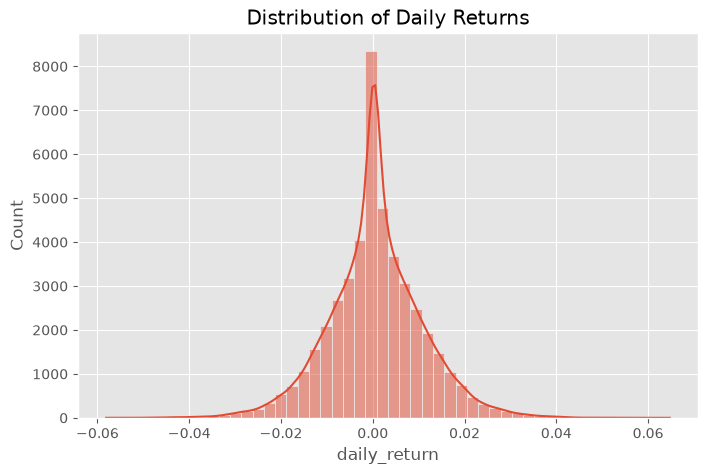

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

In [7]:
cagr = []

for code in nav_history["amfi_code"].unique():

    data = nav_history[
        nav_history["amfi_code"] == code
    ].sort_values("date")

    start_nav = data.iloc[0]["nav"]
    end_nav = data.iloc[-1]["nav"]

    years = (
        (data.iloc[-1]["date"] -
         data.iloc[0]["date"]).days
        /365
    )

    value = (
        (end_nav/start_nav)**(1/years)-1
    )

    cagr.append([code,value])

cagr = pd.DataFrame(
    cagr,
    columns=["amfi_code","CAGR"]
)

cagr.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [8]:
cagr = cagr.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

cagr.head()

,amfi_code,CAGR,scheme_name
0,100016,0.026352,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.044551,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.300997,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.235205,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.079331,ABSL Small Cap Fund - Regular - Growth


In [9]:
risk_free = 0.065

sharpe = []

for code in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"]==code
    ]["daily_return"].dropna()

    mean_return = returns.mean()*252

    std_return = returns.std()*np.sqrt(252)

    ratio = (
        mean_return-risk_free
    )/std_return

    sharpe.append([code,ratio])

sharpe = pd.DataFrame(
    sharpe,
    columns=[
        "amfi_code",
        "Sharpe"
    ]
)

In [10]:
risk_free = 0.065

sortino_list = []

for code in nav_history["amfi_code"].unique():

    fund = nav_history[nav_history["amfi_code"] == code]

    returns = fund["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    annual_return = returns.mean() * 252

    downside_std = downside_returns.std() * np.sqrt(252)

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (annual_return - risk_free) / downside_std

    sortino_list.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "Nifty 100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [12]:
alpha_beta = []

for code in nav_history["amfi_code"].unique():

    fund = nav_history[
        nav_history["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = fund.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 20:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta.append([code, alpha, beta])

alpha_beta = performance[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
].copy()

alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [13]:
alpha_beta.to_csv(
    "C:\\Users\\puvvu\\OneDrive\\ドキュメント\\MutualFundProject\\data\\processed\\alpha_beta.csv",
    index=False
)

In [14]:
drawdown_list = []

for code in nav_history["amfi_code"].unique():

    fund = nav_history[
        nav_history["amfi_code"] == code
    ].sort_values("date")

    running_max = fund["nav"].cummax()

    drawdown = (
        fund["nav"] / running_max
    ) - 1

    min_drawdown = drawdown.min()

    worst_date = fund.loc[
        drawdown.idxmin(),
        "date"
    ]

    drawdown_list.append(
        [
            code,
            min_drawdown,
            worst_date
        ]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_date"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [15]:
scorecard = performance.copy()

scorecard = scorecard.merge(
    sharpe,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name_x,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe,max_drawdown,worst_date,scheme_name_y,alpha_y,beta_y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14288,1.54,4,Moderate,1.208267,-0.150124,2024-02-05,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1231,0.66,3,Moderate,0.953279,-0.118035,2024-09-02,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,0.945308,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,-0.057187,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,24101,0.77,5,Low,-0.226575,-0.043287,2025-04-01,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [16]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha_x"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [17]:
scorecard["fund_score"] = (

    30 * scorecard["return_rank"] / scorecard["return_rank"].max()

    +

    25 * scorecard["sharpe_rank"] / scorecard["sharpe_rank"].max()

    +

    20 * scorecard["alpha_rank"] / scorecard["alpha_rank"].max()

    +

    15 * scorecard["expense_rank"] / scorecard["expense_rank"].max()

    +

    10 * scorecard["drawdown_rank"] / scorecard["drawdown_rank"].max()

)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name_x,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,worst_date,scheme_name_y,alpha_y,beta_y,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,11.16,13.58,14.26,13.04,0.54,...,2023-10-20,Mirae Asset Tax Saver Fund - Regular - Growth,0.54,0.98,23.0,38.5,39.0,36.5,21.0,80.860759
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,...,2023-11-09,ICICI Pru Bluechip Fund - Regular - Growth,0.66,0.96,33.0,33.5,37.0,20.0,14.0,76.098183
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,...,2025-02-07,Axis Bluechip Fund - Regular - Growth,1.41,0.91,31.0,31.0,17.0,39.5,15.0,70.629870
20,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Large Cap,Regular,14.37,12.25,13.42,10.98,1.27,...,2025-02-14,Kotak Bluechip Fund - Regular - Growth,1.27,0.93,28.0,29.0,19.0,35.0,24.0,68.622308
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,2024-02-05,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89,26.0,26.5,32.0,30.5,17.0,68.540071


In [18]:
scorecard.to_csv(
    "C:\\Users\\puvvu\\OneDrive\\ドキュメント\\MutualFundProject\\data\\processed\\fund_scorecard.csv",
    index=False
)

In [19]:
top5 = scorecard.head(5)["amfi_code"]

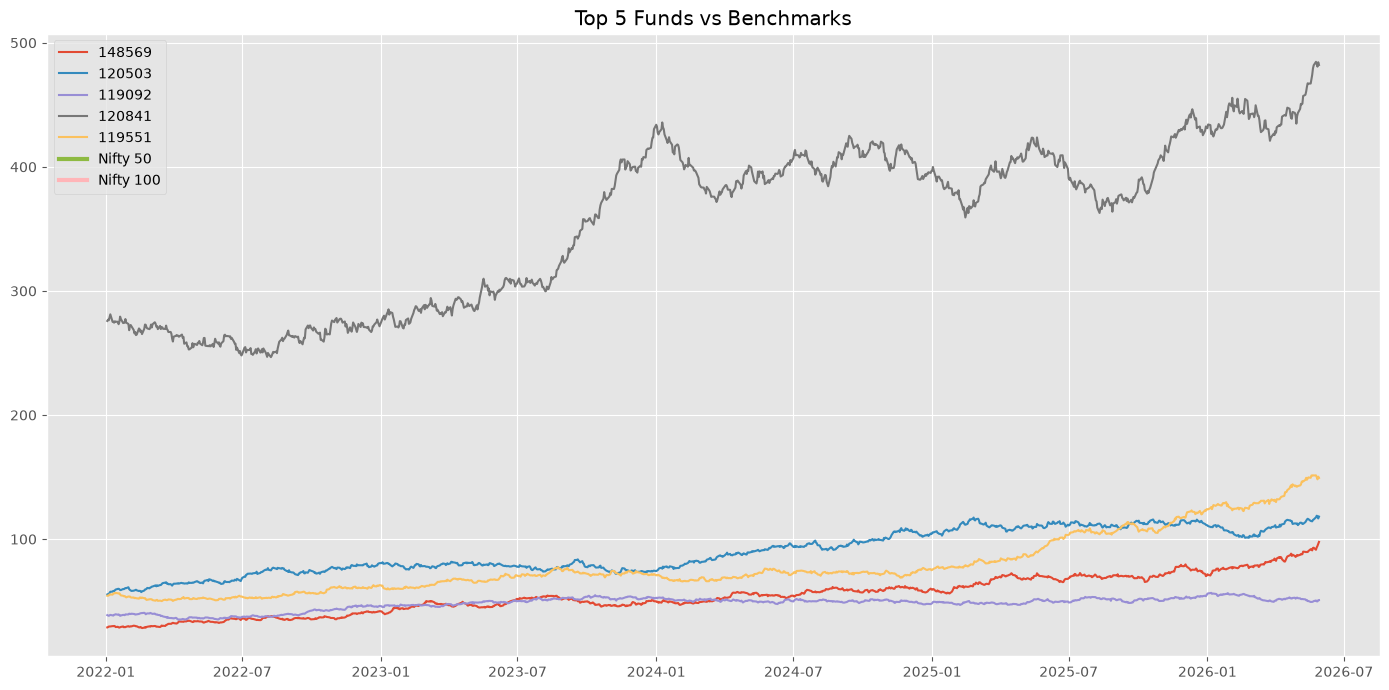

In [20]:
plt.figure(figsize=(14,7))

for code in top5:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

for name in ["Nifty 50", "Nifty 100"]:

    data = benchmark[
        benchmark["index_name"] == name
    ]

    plt.plot(
        data["date"],
        data["close_value"],
        linewidth=3,
        label=name
    )

plt.title("Top 5 Funds vs Benchmarks")

plt.legend()

plt.tight_layout()

plt.savefig(
    "C:\\Users\\puvvu\\OneDrive\\ドキュメント\\MutualFundProject\\reports\\charts\\benchmark_comparison.png"
)

plt.show()

In [21]:
tracking_error = []

for code in top5:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = fund.merge(
        nifty100[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    error = (
        merged["daily_return"] -
        merged["benchmark_return"]
    )

    te = error.std() * np.sqrt(252)

    tracking_error.append([code, te])

tracking_error = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error

,amfi_code,tracking_error
0,148569,NaN
1,120503,NaN
2,119092,NaN
3,120841,NaN
4,119551,NaN
